`summarise()` has grouped output by 'region'. You can override using the
`.groups` argument.


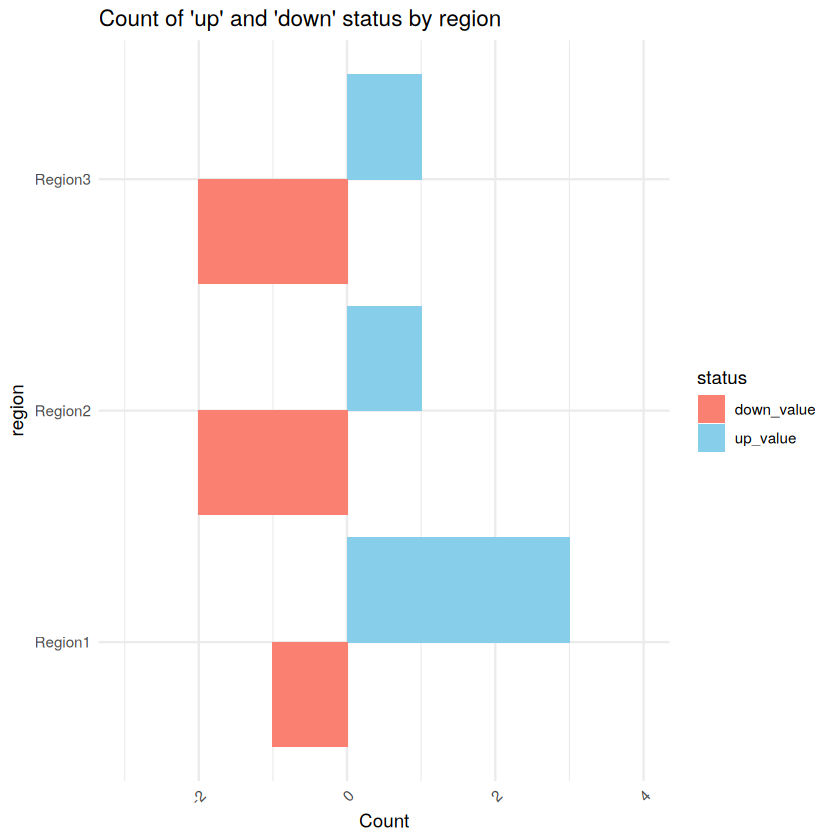

In [4]:
# Sample data frame
df <- data.frame(
  id = 1:10,
  region = c("Region1", "Region1", "Region2", "Region2", "Region3", "Region3", "Region1", "Region2", "Region3", "Region1"),
  status = c("up", "down", "up", "down", "up", "down", "up", "down", "down", "up")
)

# Summarize counts for each region and status (up/down)
library(dplyr)
library(tidyr)

summary_df <- df %>%
  group_by(region, status) %>%
  summarise(count = n()) %>%
  pivot_wider(names_from = status, values_from = count, values_fill = list(count = 0))  # Replace spread with pivot_wider

# Create a new column for plotting (with positive/negative counts)
summary_df <- summary_df %>%
  mutate(up_value = ifelse(!is.na(up), up, 0),
         down_value = ifelse(!is.na(down), -down, 0)) %>%
  select(region, up_value, down_value)

# Reshape the data to long format for plotting
long_df <- summary_df %>%
  gather(key = "status", value = "count", up_value, down_value)

# Plot the data
library(ggplot2)
ggplot(long_df, aes(x = region, y = count, fill = status)) +
  geom_bar(stat = "identity", position = "dodge") +
  coord_flip() +  # Flip to make it horizontal
  scale_y_continuous(name = "Count", limits = c(min(long_df$count) - 1, max(long_df$count) + 1)) +
  labs(title = "Count of 'up' and 'down' status by region") +
  scale_fill_manual(values = c("up_value" = "skyblue", "down_value" = "salmon")) + 
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
